In [18]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

from IPython.display import display, Math, Latex
import ipywidgets as widgets
from matplotlib.widgets import Slider, Button

from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import math

In [19]:
def Gain_DPA(Delta,kappa,lam,w):
    g = ((kappa**2/2-1j*kappa*(Delta+w))/(Delta**2+(kappa/2-1j*w)**2-lam**2)) - 1
    G = np.abs(g)**2
    return G

In [20]:
def STS_Gain(Delta,kappa,lam,w,LAM,np):
    CoeffA = (w-Delta+1j*kappa/2) - ((lam+20*np*LAM/3)**2/(-w-Delta-1j*kappa/2))
    CoeffAc = (w-Delta-1j*kappa/2) - ((lam+20*np*LAM/3)**2/(-w-Delta+1j*kappa/2))
    g = -1 + 1j * kappa / CoeffA
    gc = -1 - 1j * kappa / CoeffAc
    G = abs(g)**2
    return G

In [21]:
def JPA_Gain(Delta,kappa,lam,w,LAM,np,Kerr):

    R = w - Delta + 1j*kappa/2 + 40/9 * Kerr * np
    Rc = w - Delta - 1j*kappa/2 + 40/9 * Kerr * np
    F = -w - Delta - 1j*kappa/2 + 40/9 * Kerr * np
    Fc = -w - Delta + 1j*kappa/2 + 40/9 * Kerr * np
    gamma = lam + 20/3 * LAM * np

    denom = R - gamma**2 / F
    denomc = Rc - gamma**2 / Fc
    g = -1 + 1j * kappa / denom
    gc = -1 - 1j * kappa / denomc
    G = abs(g)**2
    return G

In [22]:
Delta=0; kappa=300*1e6*2*np.pi; lam=-0.47*kappa; Kerr = -1e-2 * kappa

In [23]:
LAM_STS = -lam*0.0004; LAM_JPA = -lam*0.0005; np1=3.11;

In [25]:
EL = 1650e9 * 2*np.pi
EC = 48e5 * 2*np.pi
w0 = np.sqrt(8*EL*EC)
print(w0/(2*np.pi))

7959899496.852959


In [26]:
DPA=[]
STS1=[]
JPA1=[]

wlist = np.linspace(-5e9*2*math.pi,5e9*2*math.pi,1001);
for w in wlist:

    DPA.append(Gain_DPA(Delta,kappa,lam,w))
    STS1.append(STS_Gain(Delta,kappa,lam,w,LAM_STS,np1))
    JPA1.append(JPA_Gain(Delta,kappa,lam,w,LAM_JPA,np1,Kerr))

    
    

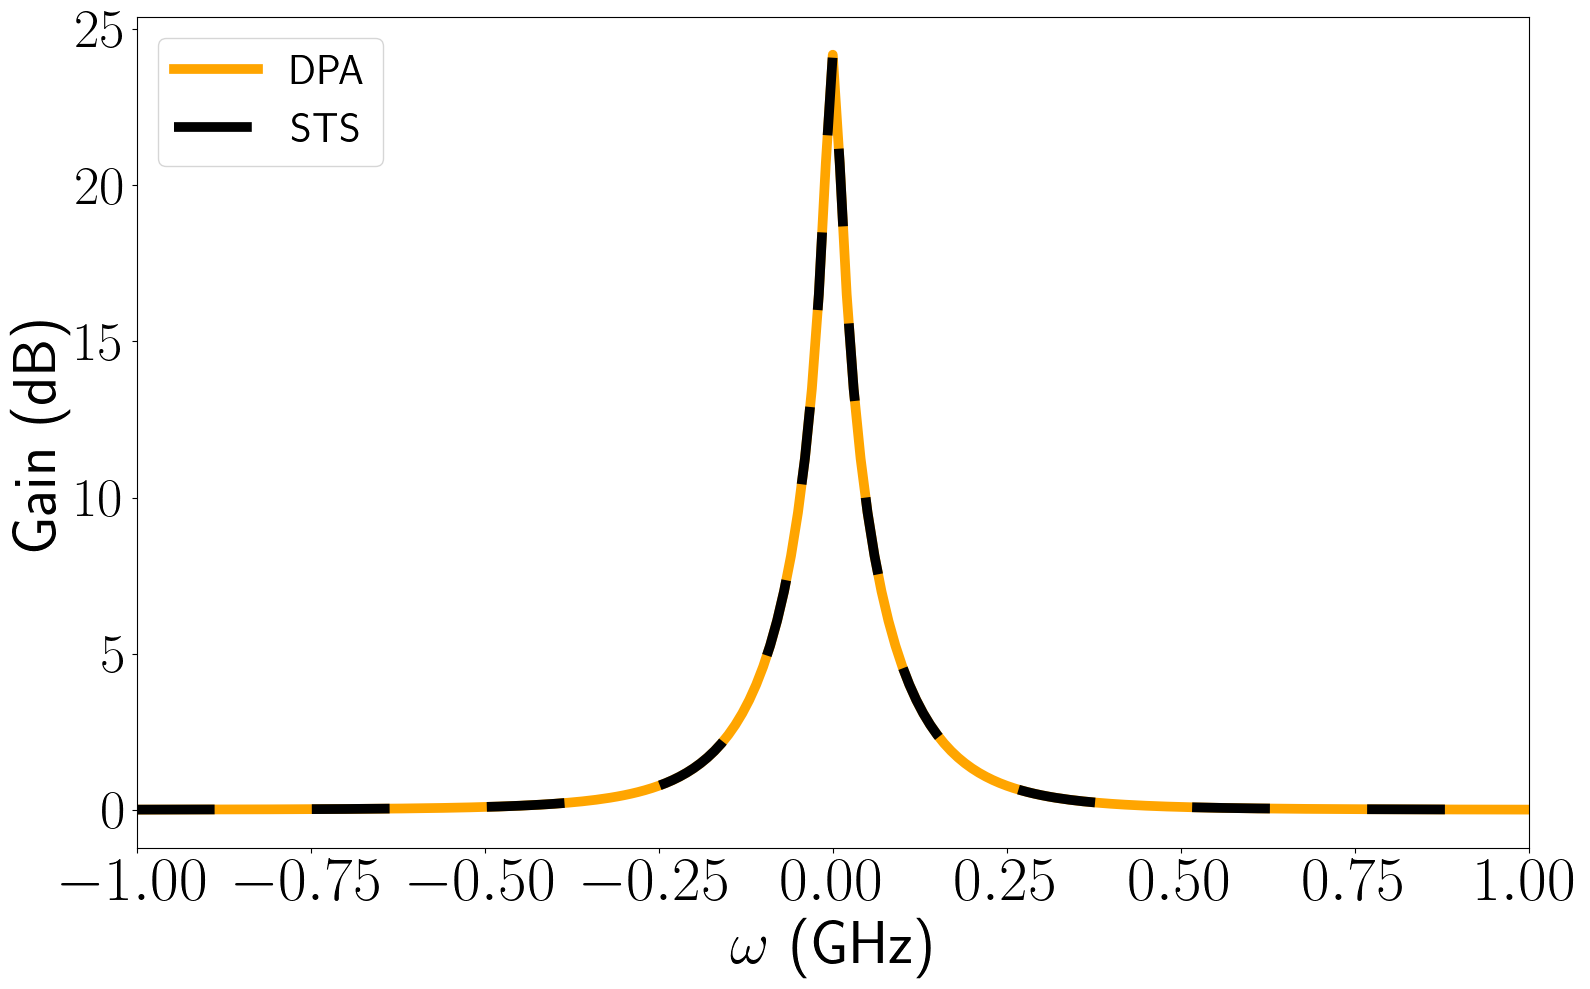

In [33]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(wlist*1e-9/(2*np.pi), 10*np.log10(DPA), c='orange', linewidth=7, label = 'DPA')
plt.plot(wlist*1e-9/(2*np.pi), 10*np.log10(DPA), c='black', linestyle=(0, (8, 10)), linewidth=7, label = 'STS')
#plt.plot(wlist*1e-9, 10*np.log10(DPA), c='red', linewidth=7, label = 'DPA')
#plt.plot(wlist*1e-9, 10*np.log10(STS1), c='black', linestyle='--', dashes=(4, 3), linewidth=5, label = r'STS: $|\Lambda|=0.0004 |\lambda|$')
#plt.plot(wlist*1e-9, 10*np.log10(JPA1), c='purple', linestyle='-.', linewidth=5, label = r'JPA: $|K|=10^{-2}\kappa, |\Lambda|=0.0005 |\lambda|$')

plt.legend(loc='upper left', fontsize=30)
plt.ylabel('Gain (dB)', fontsize=44)
plt.xlabel(r'$\omega$ (GHz)', fontsize=44)
plt.xlim(-1,1)
#plt.ylim(0,28)
#plt.title(r'$\Lambda=\lambda/235$', fontsize=40)
plt.xticks(fontsize=45)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.savefig("Gain plot analytical.jpeg")

In [31]:
wlist*1e-9

array([-31.41592654, -31.35309468, -31.29026283, ...,  31.29026283,
        31.35309468,  31.41592654], shape=(1001,))

In [28]:
import pandas as pd

In [34]:
# Sample DataFrames for demonstration
data1 = {'x_val': wlist*1e-9/(2*np.pi), 'y_val_plot1': 10*np.log10(DPA)}
df1 = pd.DataFrame(data1)

data2 = {'x_val': wlist*1e-9/(2*np.pi), 'y_val_plot2': 10*np.log10(DPA)}
df2 = pd.DataFrame(data2)

# Option 1: Concatenate if columns are different or you want to keep them separate
combined_df_option1 = pd.concat([df1, df2], axis=1)

In [35]:
# Exporting the first option (side-by-side columns)
combined_df_option1.to_csv('Gain_vs_BW.csv', index=False)


In [81]:
DPAb=[]
STS1b=[]
STS2b=[]

wlist = np.linspace(-1.5e8*2*math.pi,1.5e8*2*math.pi,100);
for w in wlist:

    DPAb.append(Gain_DPA(Delta,kappa,lam,w))
    STS1b.append(STS_Gain(Delta,kappa,lam,w,LAM1,np1))
    STS2b.append(STS_Gain(Delta,kappa,lam,w,LAM2,np1))
    
    

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.]),
 [Text(0, -2.0, '$\\mathdefault{−2}$'),
  Text(0, 0.0, '$\\mathdefault{0}$'),
  Text(0, 2.0, '$\\mathdefault{2}$'),
  Text(0, 4.0, '$\\mathdefault{4}$'),
  Text(0, 6.0, '$\\mathdefault{6}$'),
  Text(0, 8.0, '$\\mathdefault{8}$'),
  Text(0, 10.0, '$\\mathdefault{10}$'),
  Text(0, 12.0, '$\\mathdefault{12}$'),
  Text(0, 14.0, '$\\mathdefault{14}$'),
  Text(0, 16.0, '$\\mathdefault{16}$'),
  Text(0, 18.0, '$\\mathdefault{18}$')])

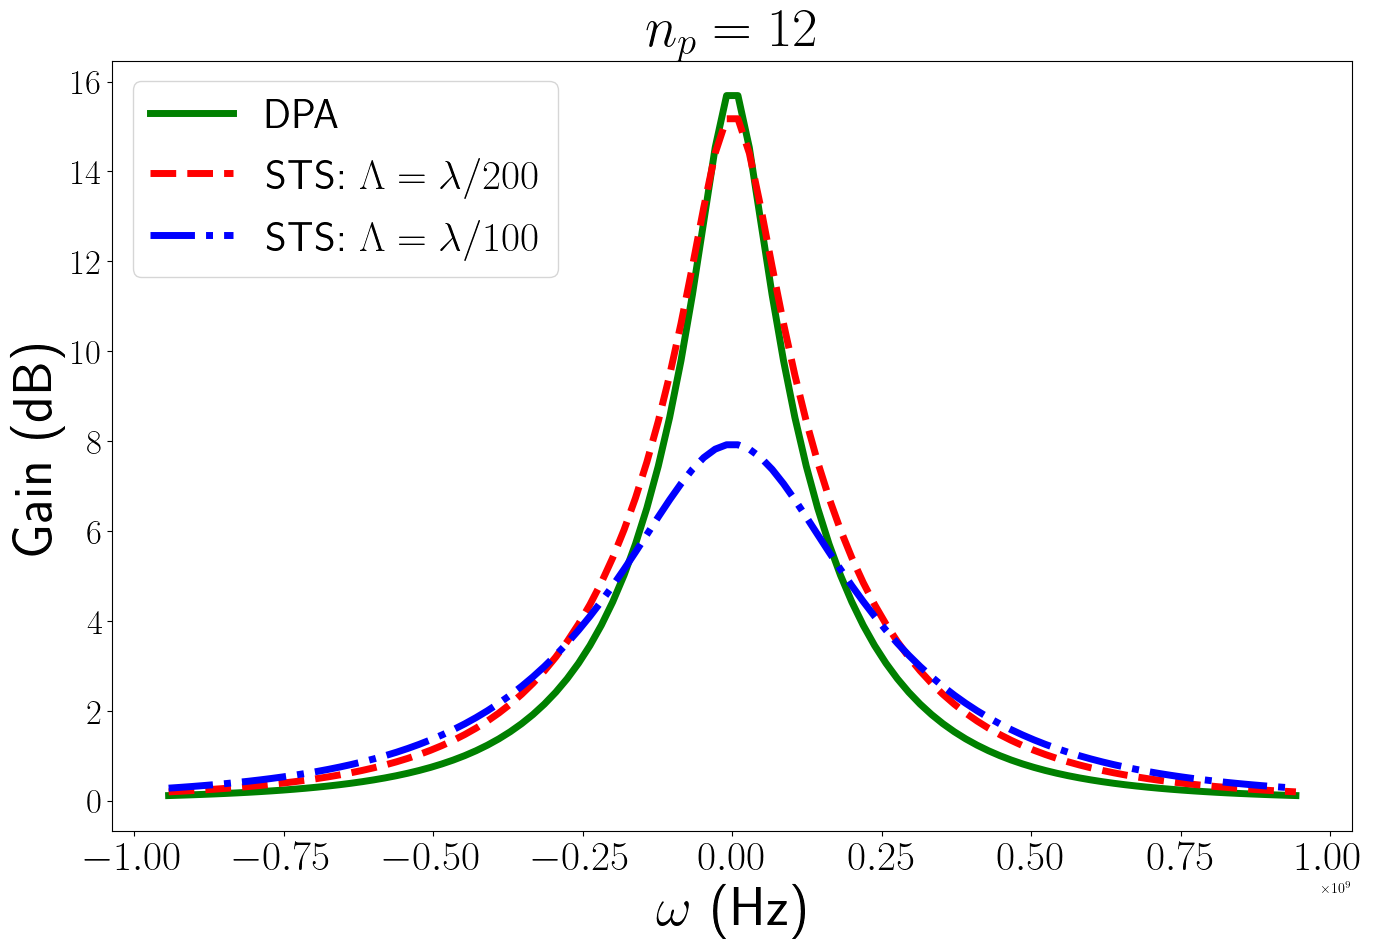

In [85]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(wlist, 10*np.log10(DPAb), c='green', linewidth=5, label = 'DPA')
plt.plot(wlist, 10*np.log10(STS1b), c='red', linestyle='--',linewidth=5, label = r'STS: $\Lambda=\lambda/200$')
plt.plot(wlist, 10*np.log10(STS2b), c='blue', linestyle='-.', linewidth=5, label = r'STS: $\Lambda=\lambda/100$')

plt.legend(loc='upper left', fontsize=30)
plt.ylabel('Gain (dB)', fontsize=40)
plt.xlabel(r'$\omega$ (Hz)', fontsize=40)
#plt.xlim(0,28)
#plt.ylim(0,28)
plt.title(r'$n_p=12$', fontsize=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=25)
#plt.savefig("Gain plot.jpeg")